## Table of Contents
1. **Data Preparation:** Load libraries, load data, 80:20 splitting
2. **Modeling & Interpretation:** Logistic Regression (GridSearchCV), Odds Ratio Analysis
3. **Model Evaluation:** Predictions, metrics, classification reports, visualizations
4. **Advanced Experiments:** Improved LR, threshold optimization, metric comparison
5. **Results Storage:** Save results & model artifacts
6. **Conclusion:** Final model selection & key takeaways

## 1. Data Preparation

### 1.1 Load Libraries

In [77]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, cohen_kappa_score,
    classification_report
)
from scipy.stats import gmean
import statsmodels.api as sm
import joblib
import warnings
warnings.filterwarnings('ignore')

### 1.2 Load Processed Data

In [78]:
# Load Processed Data
df = pd.read_csv('Data/heart_cleaned.csv')
print(f"Data shape: {df.shape}")

# Separate features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}\n")

Data shape: (918, 19)
Features shape: (918, 18)
Target shape: (918,)
Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64



### 1.3 Splitting Dataset (80:20)

In [79]:
# Splitting Dataset 80:20 (train_test_split)
X_cv, X_test, y_cv, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train (CV) shape: {X_cv.shape}")
print(f"Test shape      : {X_test.shape}")
print(f"Train target distribution:\n{y_cv.value_counts()}\n")
print(f"Test target distribution:\n{y_test.value_counts()}\n")


Train (CV) shape: (734, 18)
Test shape      : (184, 18)
Train target distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64

Test target distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64



## 2. Modeling & Interpretation

### 2.1 Logistic Regression Baseline (GridSearchCV)

In [80]:
# Train Logistic Regression as a baseline comparison model
print("="*50)
print("LOGISTIC REGRESSION MODEL")
print("="*50)

logreg_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear']
}

print("Logistic Regression Parameter Grid:")
for key, value in logreg_param_grid.items():
    print(f"  {key}: {value}")

logreg_base = LogisticRegression(random_state=42, max_iter=1000)
logreg_grid_search = GridSearchCV(
    logreg_base,
    logreg_param_grid,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nTraining Logistic Regression with GridSearchCV (5-Fold CV)...")
logreg_grid_search.fit(X_cv, y_cv)

best_logreg_model = logreg_grid_search.best_estimator_
best_logreg_params = logreg_grid_search.best_params_

print(f"\nBest Logistic Regression Parameters Found:")
for key, value in best_logreg_params.items():
    print(f"  {key}: {value}")
print(f"Best CV ROC-AUC Score: {logreg_grid_search.best_score_:.4f}\n")

LOGISTIC REGRESSION MODEL
Logistic Regression Parameter Grid:
  C: [0.1, 1, 10]
  solver: ['liblinear']

Training Logistic Regression with GridSearchCV (5-Fold CV)...
Fitting 10 folds for each of 3 candidates, totalling 30 fits

Best Logistic Regression Parameters Found:
  C: 0.1
  solver: liblinear
Best CV ROC-AUC Score: 0.9185



### 2.2 Odds Ratio Analysis (statsmodels)

Reference categories (dummy variable trap avoidance):
- **ChestPainType** > `ASY` (Asymptomatic)
- **RestingECG** > `Normal`
- **ST_Slope** > `Up` (Normal slope)

In [81]:
# Fit a statsmodels logistic regression for odds ratio interpretation
print("="*50)
print("ODDS RATIO ANALYSIS")
print("="*50)

# --- Drop 1 reference category per multiclass dummy feature ---
# This avoids the dummy variable trap (multicollinearity) so statsmodels
# can invert the design matrix without producing NaN / inf coefficients.
reference_categories = {
    'ChestPainType': 'ASY',   # Asymptomatic > baseline
    'RestingECG':    'Normal', # Normal ECG   > baseline
    'ST_Slope':      'Up',     # Normal slope > baseline
}

cols_to_drop = []
for feat, ref in reference_categories.items():
    col_name = f"{feat}_{ref}"
    if col_name in X_cv.columns:
        cols_to_drop.append(col_name)
        print(f"  Reference: {col_name}")
    else:
        print(f"  Column {col_name} not found — already absent")

print(f"\nDropped {len(cols_to_drop)} reference column(s): {cols_to_drop}\n")

X_cv_or = X_cv.drop(columns=cols_to_drop)
X_cv_or = sm.add_constant(X_cv_or.astype(float), has_constant='add')
logit_sm = sm.Logit(y_cv, X_cv_or).fit(disp=False)

conf_int = logit_sm.conf_int()
odds_ratio_df = pd.DataFrame({
    'Feature': X_cv_or.columns[1:],       # exclude constant
    'Coefficient': logit_sm.params.iloc[1:].values,
    'Odds_Ratio': np.exp(logit_sm.params.iloc[1:].values),
    'CI_Lower': np.exp(conf_int.iloc[1:, 0].values),
    'CI_Upper': np.exp(conf_int.iloc[1:, 1].values),
    'P_Value': logit_sm.pvalues.iloc[1:].values
})

odds_ratio_df = odds_ratio_df.sort_values('P_Value').reset_index(drop=True)
print(odds_ratio_df.to_string(index=False))

significant_features = odds_ratio_df[odds_ratio_df['P_Value'] < 0.05]
if not significant_features.empty:
    print("\nSignificant predictors (p < 0.05):")
    print(significant_features.to_string(index=False))

odds_ratio_df.to_csv('outputs/logistic_regression_odds_ratio.csv', index=False)
print("\nSaved: outputs/logistic_regression_odds_ratio.csv")

ODDS RATIO ANALYSIS
  Reference: ChestPainType_ASY
  Reference: RestingECG_Normal
  Reference: ST_Slope_Up

Dropped 3 reference column(s): ['ChestPainType_ASY', 'RestingECG_Normal', 'ST_Slope_Up']

          Feature  Coefficient  Odds_Ratio  CI_Lower  CI_Upper      P_Value
    ST_Slope_Flat     2.451427   11.604891  6.814662 19.762315 1.789335e-19
ChestPainType_NAP    -1.822109    0.161684  0.090524  0.288785 7.414722e-10
ChestPainType_ATA    -1.772117    0.169973  0.084812  0.340646 5.851680e-07
              Sex     1.433976    4.195348  2.281950  7.713115 3.922972e-06
        FastingBS     1.306712    3.694007  2.029119  6.724934 1.912640e-05
 ChestPainType_TA    -1.482397    0.227093  0.092933  0.554928 1.146650e-03
   ExerciseAngina     0.836635    2.308587  1.365156  3.904003 1.801152e-03
    ST_Slope_Down     1.570788    4.810439  1.621795 14.268340 4.631333e-03
            MaxHR    -0.010972    0.989088  0.978592  0.999698 4.385426e-02
          Oldpeak     0.236349    1.266616

## 3. Model Evaluation

### 3.1 Evaluation: Predictions & Metrics

In [82]:
# EVALUATE: Make predictions on CV and test data
# Logistic Regression predictions
y_pred_cv_lr = best_logreg_model.predict(X_cv)
y_pred_proba_cv_lr = best_logreg_model.predict_proba(X_cv)[:, 1]

y_pred_test_lr = best_logreg_model.predict(X_test)
y_pred_proba_test_lr = best_logreg_model.predict_proba(X_test)[:, 1]

# Function to calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    # Calculate Specificity and G-Mean
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall/Sensitivity
    tnr = specificity  # Specificity
    g_mean = gmean([tpr, tnr])
    
    cm = confusion_matrix(y_true, y_pred)
    
    metrics_dict = {
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Kappa': kappa,
        'G-Mean': g_mean,
        'Confusion_Matrix': cm
    }
    
    return metrics_dict

# Calculate metrics for both datasets
metrics_cv_lr = calculate_metrics(y_cv, y_pred_cv_lr, y_pred_proba_cv_lr, 'CV (Train)')
metrics_test_lr = calculate_metrics(y_test, y_pred_test_lr, y_pred_proba_test_lr, 'Test (Blind)')

### 3.2 Metrics Summary

In [83]:
# Display metrics
print("\n" + "="*50)
print("METRICS SUMMARY")
print("="*50)

lr_metrics_summary = pd.DataFrame([
    {
        'Dataset': 'CV (Train)',
        'Accuracy': f"{metrics_cv_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_cv_lr['Precision']:.4f}",
        'Recall': f"{metrics_cv_lr['Recall']:.4f}",
        'Specificity': f"{metrics_cv_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_cv_lr['F1-Score']:.4f}",
        'G-Mean': f"{metrics_cv_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_cv_lr['ROC-AUC']:.4f}"
    },
    {
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_test_lr['Precision']:.4f}",
        'Recall': f"{metrics_test_lr['Recall']:.4f}",
        'Specificity': f"{metrics_test_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_test_lr['F1-Score']:.4f}",
        'G-Mean': f"{metrics_test_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test_lr['ROC-AUC']:.4f}"
    }
])

print("\nLogistic Regression Metrics")
print(lr_metrics_summary.to_string(index=False))


METRICS SUMMARY

Logistic Regression Metrics
     Dataset Accuracy Precision Recall Specificity F1-Score G-Mean ROC-AUC
  CV (Train)   0.8542    0.8585 0.8818      0.8201   0.8700 0.8504  0.9266
Test (Blind)   0.8913    0.8942 0.9118      0.8659   0.9029 0.8885  0.9340


### 3.3 Classification Reports

In [84]:
# Classification Reports
print("\n" + "="*50)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION - CV (TRAIN)")
print("="*50)
print(classification_report(y_cv, y_pred_cv_lr, target_names=['No Disease', 'Has Disease']))

print("\n" + "="*50)
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION - TEST (BLIND)")
print("="*50)
print(classification_report(y_test, y_pred_test_lr, target_names=['No Disease', 'Has Disease']))


CLASSIFICATION REPORT - LOGISTIC REGRESSION - CV (TRAIN)
              precision    recall  f1-score   support

  No Disease       0.85      0.82      0.83       328
 Has Disease       0.86      0.88      0.87       406

    accuracy                           0.85       734
   macro avg       0.85      0.85      0.85       734
weighted avg       0.85      0.85      0.85       734


CLASSIFICATION REPORT - LOGISTIC REGRESSION - TEST (BLIND)
              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        82
 Has Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### 3.4 Visualizations


GENERATING VISUALIZATIONS


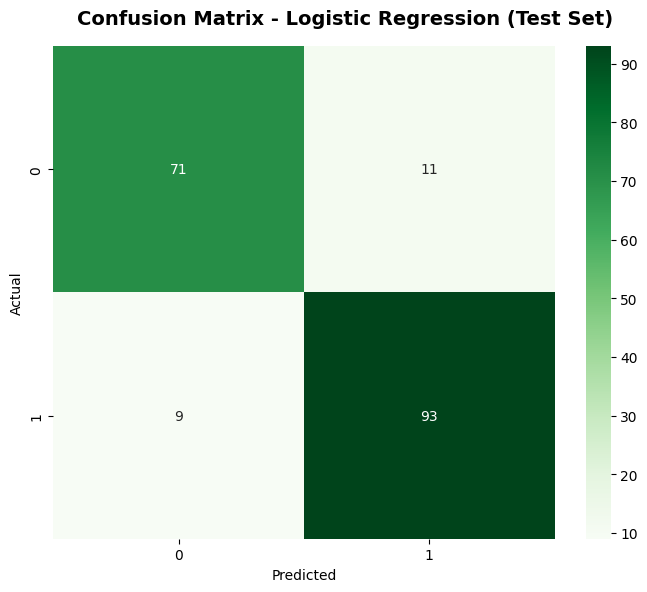

Saved: outputs/LRconfusion_matrix.png


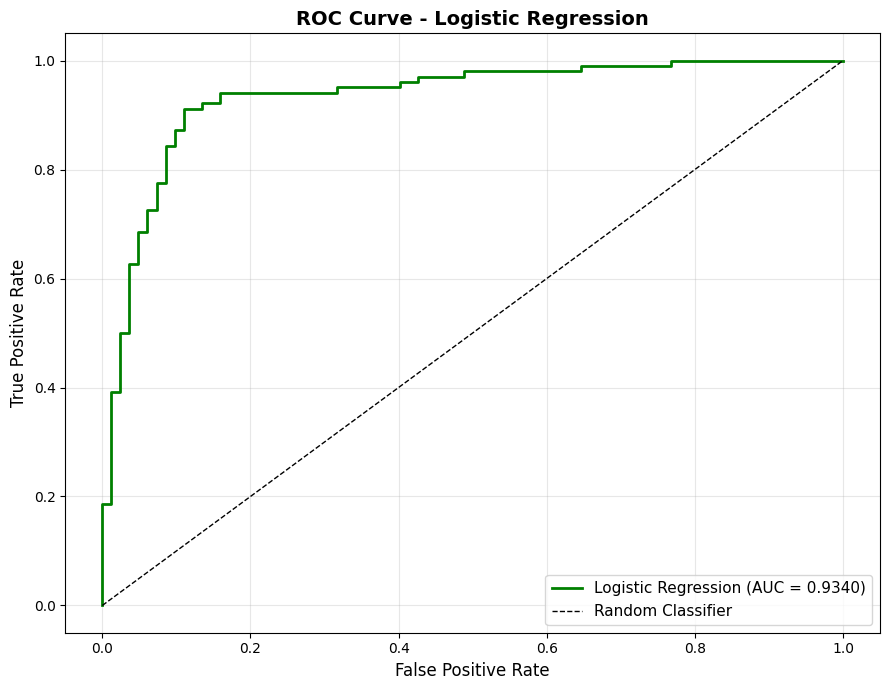

Saved: outputs/LRroc_curve.png


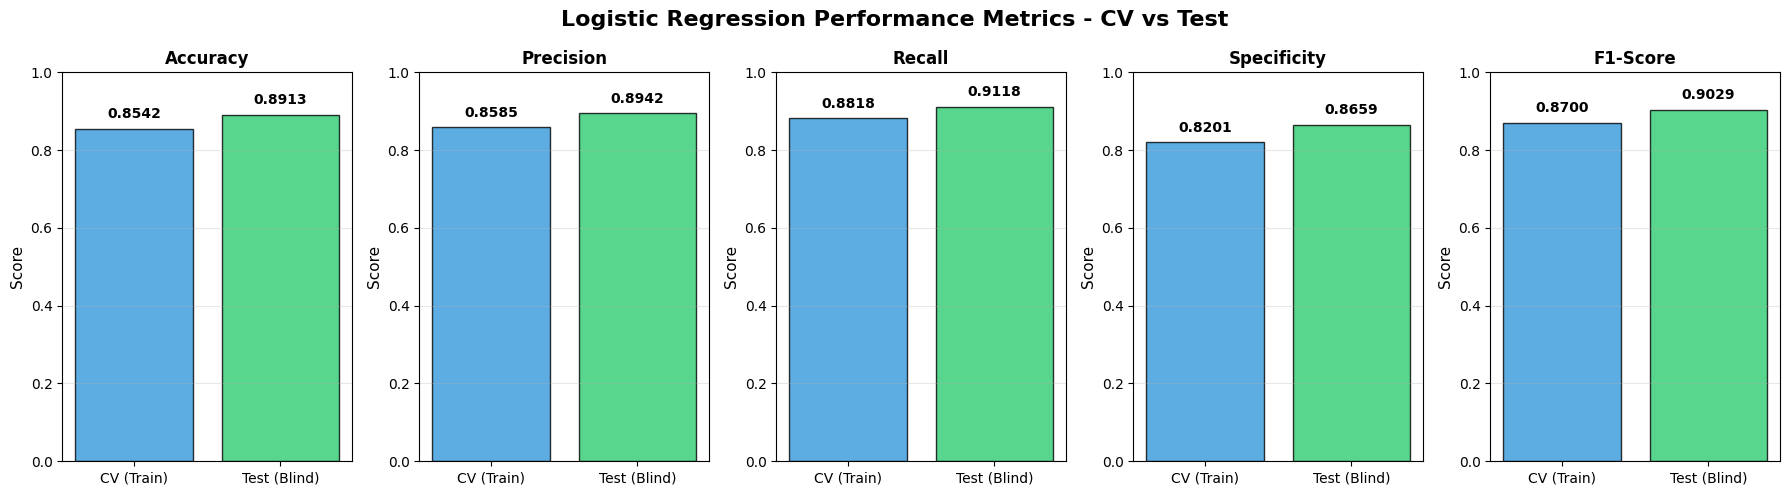

Saved: outputs/LRmetrics.png


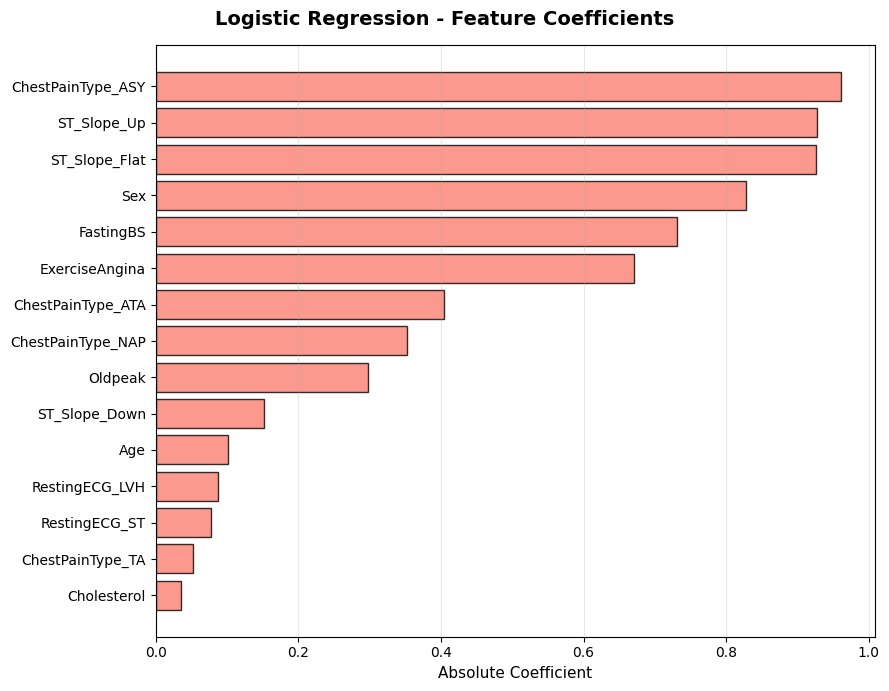

Saved: outputs/LRfeature_importance.png


In [85]:
# VISUALIZATIONS
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# 1. Confusion Matrix for Logistic Regression (Test Set)
fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Confusion Matrix - Logistic Regression (Test Set)', fontsize=14, fontweight='bold')

cm_lr_test = confusion_matrix(y_test, y_pred_test_lr)

sns.heatmap(cm_lr_test, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('outputs/LRconfusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/LRconfusion_matrix.png")

# 2. ROC Curve for Logistic Regression (Test Set)
fig, ax = plt.subplots(figsize=(9, 7))

fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test, y_pred_proba_test_lr)
roc_auc_lr_test = roc_auc_score(y_test, y_pred_proba_test_lr)

ax.plot(fpr_lr_test, tpr_lr_test, label=f'Logistic Regression (AUC = {roc_auc_lr_test:.4f})', linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/LRroc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/LRroc_curve.png")

# 3. Metrics Comparison Bar Plot (CV vs Test)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Logistic Regression Performance Metrics - CV vs Test', fontsize=16, fontweight='bold')

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
datasets = ['CV (Train)', 'Test (Blind)']
colors_bars = ['#3498db', '#2ecc71']

for idx, metric_name in enumerate(metrics_names):
    ax = axes[idx]
    
    metric_key = metric_name.replace(' ', '_').replace('-', '_')
    if metric_key == 'F1_Score':
        metric_key = 'F1-Score'
    
    cv_value = metrics_cv_lr[metric_key]
    test_value = metrics_test_lr[metric_key]
    
    bars = ax.bar(datasets, [cv_value, test_value], color=colors_bars, alpha=0.8, edgecolor='black')
    
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, axis='y', alpha=0.3)
    
    for bar, value in zip(bars, [cv_value, test_value]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/LRmetrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/LRmetrics.png")

# 4. Logistic Regression Coefficients
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Logistic Regression - Feature Coefficients', fontsize=14, fontweight='bold')

feature_names = X.columns

logreg_coefficients = np.abs(best_logreg_model.coef_[0])
logreg_indices = np.argsort(logreg_coefficients)[-15:]
ax.barh(range(len(logreg_indices)), logreg_coefficients[logreg_indices], color='salmon', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(logreg_indices)))
ax.set_yticklabels([feature_names[i] for i in logreg_indices], fontsize=10)
ax.set_xlabel('Absolute Coefficient', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/LRfeature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: outputs/LRfeature_importance.png")

## 4. Advanced Experiments (Comparison Model)

### 4.1 Improved Logistic Regression (Comparison Model)

In [86]:
# IMPROVED LOGISTIC REGRESSION (NO FILE SAVING - ONLY METRICS DISPLAY)
# Extra import needed for threshold optimization (kept local to avoid touching cell 1)
from sklearn.metrics import precision_recall_curve

print("="*50)
print("IMPROVED LOGISTIC REGRESSION")
print("="*50)

# --- Expanded hyperparameter grid ---
logreg2_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

print("Improved Logistic Regression Parameter Grid:")
for key, value in logreg2_param_grid.items():
    print(f"  {key}: {value}")

logreg2_base = LogisticRegression(random_state=42, max_iter=2000)
logreg2_grid_search = GridSearchCV(
    logreg2_base,
    logreg2_param_grid,
    cv=10,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print("\nTraining Improved Logistic Regression with GridSearchCV (10-Fold CV)...")
logreg2_grid_search.fit(X_cv, y_cv)

best_logreg2_model = logreg2_grid_search.best_estimator_
best_logreg2_params = logreg2_grid_search.best_params_

print(f"\nBest Improved Logistic Regression Parameters Found:")
for key, value in best_logreg2_params.items():
    print(f"  {key}: {value}")
print(f"Best CV ROC-AUC Score: {logreg2_grid_search.best_score_:.4f}\n")

# --- Check L1 feature selection effect ---
if 'l1' in best_logreg2_params.get('penalty', ''):
    zero_coefs = np.sum(best_logreg2_model.coef_[0] == 0)
    print(f"Penalty L1 Active — {zero_coefs} from {X_cv.shape[1]} feature that has 0 coef (Drop)\n")
else:
    print("Best model use L2 penalty\n")

IMPROVED LOGISTIC REGRESSION
Improved Logistic Regression Parameter Grid:
  C: [0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  class_weight: [None, 'balanced']

Training Improved Logistic Regression with GridSearchCV (10-Fold CV)...

Best Improved Logistic Regression Parameters Found:
  C: 0.1
  class_weight: balanced
  penalty: l1
  solver: liblinear
Best CV ROC-AUC Score: 0.9195

Penalty L1 Active — 9 from 18 feature that has 0 coef (Drop)



In [87]:
used_features = X_cv.columns[best_logreg2_model.coef_[0] != 0]
print("Used Features:", list(used_features))
print("Dropped Features:", list(X_cv.columns[best_logreg2_model.coef_[0] == 0]))

Used Features: ['Age', 'Sex', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ST_Slope_Flat', 'ST_Slope_Up']
Dropped Features: ['RestingBP', 'Cholesterol', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down']


**Why use the F1-Score as the threshold criterion?**

1. **F1 involves both types of errors.** F1 is the harmonic mean of precision (representing *False Positives*) and recall (representing *False Negatives*) FP and FN are treated equally, without a subjective assumption that one is more costly than the other.
2. **The harmonic mean penalizes extreme values.** Unlike the arithmetic mean, F1 drops drastically if one component is low, the optimized threshold will not sacrifice either side to an extreme.
3. **Neutral & objective.** Without clinical cost data (cost of FP vs cost of FN), weighting one error more than the other is a subjective decision. F1 is a neutral, defensible choice.
4. **Consistent across models.** Both the Baseline and Improved LR are optimized with the F1 criterion, the comparison between models is *fair* (apple-to-apple).
5. **Clinically relevant.** False Positives are also risky: healthy patients may undergo further invasive procedures (e.g., angiography) that are actually unnecessary.
6. **Supported by the literature.** The F1-Score is a commonly used threshold criterion in medical classification studies when there is no explicit cost preference.

### 4.2 Threshold Optimization, Improved LR

In [88]:
# THRESHOLD OPTIMIZATION + METRICS COMPARISON (NO FILE SAVING)
print("="*50)
print("THRESHOLD OPTIMIZATION")
print("="*50)

# Predict probabilities on CV (for threshold tuning) and test (for evaluation)
y_pred_proba_cv2 = best_logreg2_model.predict_proba(X_cv)[:, 1]
y_pred_proba_test2 = best_logreg2_model.predict_proba(X_test)[:, 1]

# Find optimal threshold on CV set (maximize F1-score balance)
prec_cv, rec_cv, thresholds_cv = precision_recall_curve(y_cv, y_pred_proba_cv2)
f1_scores = 2 * (prec_cv * rec_cv) / (prec_cv + rec_cv + 1e-12)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds_cv[best_threshold_idx]
print(f"Optimal threshold (max F1 on CV): {best_threshold:.4f}")

# Baseline predictions (threshold = 0.5)
y_pred_cv2 = (y_pred_proba_cv2 >= 0.5).astype(int)
y_pred_test2 = (y_pred_proba_test2 >= 0.5).astype(int)

# Adjusted predictions (optimal threshold)
y_pred_test2_adj = (y_pred_proba_test2 >= best_threshold).astype(int)

# Metrics with default threshold (0.5)
metrics_cv2 = calculate_metrics(y_cv, y_pred_cv2, y_pred_proba_cv2, 'CV (Train)')
metrics_test2 = calculate_metrics(y_test, y_pred_test2, y_pred_proba_test2, 'Test (Blind)')

# Metrics with optimal threshold
metrics_test2_adj = calculate_metrics(y_test, y_pred_test2_adj, y_pred_proba_test2, 'Test (Blind) - Opt Threshold')


THRESHOLD OPTIMIZATION
Optimal threshold (max F1 on CV): 0.3821


### 4.3 Threshold Optimization, Baseline LR

In [89]:
# LR BASELINE - THRESHOLD OPTIMIZATION
print("="*50)
print("LR BASELINE - THRESHOLD OPTIMIZATION")
print("="*50)

# y_pred_proba_cv_lr & y_pred_proba_test_lr has already defined

# Find optimal threshold on CV set (maximize F1-score balance)
prec_cv_base, rec_cv_base, thresholds_cv_base = precision_recall_curve(y_cv, y_pred_proba_cv_lr)
f1_scores_base = 2 * (prec_cv_base * rec_cv_base) / (prec_cv_base + rec_cv_base + 1e-12)
best_threshold_idx_base = np.argmax(f1_scores_base)
best_threshold_base = thresholds_cv_base[best_threshold_idx_base]
print(f"Optimal threshold LR Baseline (max F1 on CV): {best_threshold_base:.4f}")

# Adjusted predictions (optimal threshold)
y_pred_test_lr_adj = (y_pred_proba_test_lr >= best_threshold_base).astype(int)

# Metrics with optimal threshold
metrics_test_lr_adj = calculate_metrics(y_test, y_pred_test_lr_adj, y_pred_proba_test_lr, 'Test (Blind) - Opt Threshold')


LR BASELINE - THRESHOLD OPTIMIZATION
Optimal threshold LR Baseline (max F1 on CV): 0.3573


### 4.4 Metrics Comparison: Baseline vs Improved LR

In [90]:
# DISPLAY METRICS COMPARISON: BASELINE LR vs IMPROVED LR
print("="*50)
print("METRICS COMPARISON: BASELINE LR vs IMPROVED LR")
print("="*50)

comparison_df = pd.DataFrame([
    {
        'Model': 'LR Baseline',
        'Dataset': 'CV (Train)',
        'Accuracy': f"{metrics_cv_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_cv_lr['Precision']:.4f}",
        'Recall': f"{metrics_cv_lr['Recall']:.4f}",
        'Specificity': f"{metrics_cv_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_cv_lr['F1-Score']:.4f}",
        'G-Mean': f"{metrics_cv_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_cv_lr['ROC-AUC']:.4f}"
    },
    {
        'Model': 'LR Baseline',
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test_lr['Accuracy']:.4f}",
        'Precision': f"{metrics_test_lr['Precision']:.4f}",
        'Recall': f"{metrics_test_lr['Recall']:.4f}",
        'Specificity': f"{metrics_test_lr['Specificity']:.4f}",
        'F1-Score': f"{metrics_test_lr['F1-Score']:.4f}",
        'G-Mean': f"{metrics_test_lr['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test_lr['ROC-AUC']:.4f}"
    },
    {
        'Model': 'LR Baseline (Opt Threshold)',
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test_lr_adj['Accuracy']:.4f}",
        'Precision': f"{metrics_test_lr_adj['Precision']:.4f}",
        'Recall': f"{metrics_test_lr_adj['Recall']:.4f}",
        'Specificity': f"{metrics_test_lr_adj['Specificity']:.4f}",
        'F1-Score': f"{metrics_test_lr_adj['F1-Score']:.4f}",
        'G-Mean': f"{metrics_test_lr_adj['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test_lr_adj['ROC-AUC']:.4f}"
    },
    {
        'Model': 'LR Improved',
        'Dataset': 'CV (Train)',
        'Accuracy': f"{metrics_cv2['Accuracy']:.4f}",
        'Precision': f"{metrics_cv2['Precision']:.4f}",
        'Recall': f"{metrics_cv2['Recall']:.4f}",
        'Specificity': f"{metrics_cv2['Specificity']:.4f}",
        'F1-Score': f"{metrics_cv2['F1-Score']:.4f}",
        'G-Mean': f"{metrics_cv2['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_cv2['ROC-AUC']:.4f}"
    },
    {
        'Model': 'LR Improved',
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test2['Accuracy']:.4f}",
        'Precision': f"{metrics_test2['Precision']:.4f}",
        'Recall': f"{metrics_test2['Recall']:.4f}",
        'Specificity': f"{metrics_test2['Specificity']:.4f}",
        'F1-Score': f"{metrics_test2['F1-Score']:.4f}",
        'G-Mean': f"{metrics_test2['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test2['ROC-AUC']:.4f}"
    },
    {
        'Model': 'LR Improved (Opt Threshold)',
        'Dataset': 'Test (Blind)',
        'Accuracy': f"{metrics_test2_adj['Accuracy']:.4f}",
        'Precision': f"{metrics_test2_adj['Precision']:.4f}",
        'Recall': f"{metrics_test2_adj['Recall']:.4f}",
        'Specificity': f"{metrics_test2_adj['Specificity']:.4f}",
        'F1-Score': f"{metrics_test2_adj['F1-Score']:.4f}",
        'G-Mean': f"{metrics_test2_adj['G-Mean']:.4f}",
        'ROC-AUC': f"{metrics_test2_adj['ROC-AUC']:.4f}"
    }
])

print(comparison_df.to_string(index=False))

print("\n" + "="*50)
print("METRICS SUMMARY")
print("="*50)
print(f"Best params LR Improved : {best_logreg2_params}")
print(f"Optimal threshold LR Baseline : {best_threshold_base:.4f}")
print(f"Optimal threshold LR Improved : {best_threshold:.4f}")

# Calculate improvement on test set
acc_gain = metrics_test2['Accuracy'] - metrics_test_lr['Accuracy']
auc_gain = metrics_test2['ROC-AUC'] - metrics_test_lr['ROC-AUC']
spec_gain = metrics_test2_adj['Specificity'] - metrics_test_lr['Specificity']

print(f"\nChanges from LR Improved vs LR Baseline (Test):")
print(f"  Accuracy   : {acc_gain:+.4f}")
print(f"  ROC-AUC    : {auc_gain:+.4f}")
print(f"  Specificity (opt threshold): {spec_gain:+.4f}")
print("\nImproved LR metrics displayed (no files saved)")


METRICS COMPARISON: BASELINE LR vs IMPROVED LR
                      Model      Dataset Accuracy Precision Recall Specificity F1-Score G-Mean ROC-AUC
                LR Baseline   CV (Train)   0.8542    0.8585 0.8818      0.8201   0.8700 0.8504  0.9266
                LR Baseline Test (Blind)   0.8913    0.8942 0.9118      0.8659   0.9029 0.8885  0.9340
LR Baseline (Opt Threshold) Test (Blind)   0.8696    0.8421 0.9412      0.7805   0.8889 0.8571  0.9340
                LR Improved   CV (Train)   0.8529    0.8725 0.8596      0.8445   0.8660 0.8520  0.9263
                LR Improved Test (Blind)   0.8804    0.9167 0.8627      0.9024   0.8889 0.8824  0.9289
LR Improved (Opt Threshold) Test (Blind)   0.8913    0.8727 0.9412      0.8293   0.9057 0.8835  0.9289

METRICS SUMMARY
Best params LR Improved : {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Optimal threshold LR Baseline : 0.3573
Optimal threshold LR Improved : 0.3821

Changes from LR Improved vs LR 

In [ ]:
# ADDITIONAL METRICS: MCC & PR-AUC
from sklearn.metrics import matthews_corrcoef, average_precision_score

print("="*50)
print("ADDITIONAL METRICS: MCC & PR-AUC")
print("="*50)

variants = [
    ('LR Baseline',                'CV (Train)',              y_cv, y_pred_cv_lr,         y_pred_proba_cv_lr),
    ('LR Baseline',                'Test (Blind)',            y_test, y_pred_test_lr,     y_pred_proba_test_lr),
    ('LR Baseline (Opt Threshold)','Test (Blind)',            y_test, y_pred_test_lr_adj, y_pred_proba_test_lr),
    ('LR Improved',                'CV (Train)',              y_cv, y_pred_cv2,           y_pred_proba_cv2),
    ('LR Improved',                'Test (Blind)',            y_test, y_pred_test2,       y_pred_proba_test2),
    ('LR Improved (Opt Threshold)','Test (Blind)',            y_test, y_pred_test2_adj,   y_pred_proba_test2),
]

mcc_map = {}
prauc_map = {}

for model, dataset, y_true, y_pred, y_proba in variants:
    mcc = matthews_corrcoef(y_true, y_pred)
    prauc = average_precision_score(y_true, y_proba)
    mcc_map[(model, dataset)] = mcc
    prauc_map[(model, dataset)] = prauc
    print(f"{model:32s} | {dataset:22s} | MCC = {mcc:.4f} | PR-AUC = {prauc:.4f}")

# Tambahkan kolom MCC & PR-AUC ke tabel perbandingan yang sudah ada
comparison_df['MCC'] = comparison_df.apply(
    lambda row: f"{mcc_map[(row['Model'], row['Dataset'])]:.4f}", axis=1)
comparison_df['PR-AUC'] = comparison_df.apply(
    lambda row: f"{prauc_map[(row['Model'], row['Dataset'])]:.4f}", axis=1)

# Add G-Mean column (consistent with previous tables: between F1-Score and ROC-AUC)
gmean_map = {
    ('LR Baseline', 'CV (Train)'): metrics_cv_lr['G-Mean'],
    ('LR Baseline', 'Test (Blind)'): metrics_test_lr['G-Mean'],
    ('LR Baseline (Opt Threshold)', 'Test (Blind)'): metrics_test_lr_adj['G-Mean'],
    ('LR Improved', 'CV (Train)'): metrics_cv2['G-Mean'],
    ('LR Improved', 'Test (Blind)'): metrics_test2['G-Mean'],
    ('LR Improved (Opt Threshold)', 'Test (Blind)'): metrics_test2_adj['G-Mean'],
}
comparison_df['G-Mean'] = comparison_df.apply(
    lambda row: f"{gmean_map[(row['Model'], row['Dataset'])]:.4f}", axis=1)

# Reorder columns: place G-Mean between F1-Score and ROC-AUC
column_order = ['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'Specificity',
                'F1-Score', 'G-Mean', 'ROC-AUC', 'MCC', 'PR-AUC']
comparison_df = comparison_df[column_order]

print("\n" + "="*50)
print("FINAL TABLE COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))

ADDITIONAL METRICS: MCC & PR-AUC
LR Baseline                      | CV (Train)             | MCC = 0.7045 | PR-AUC = 0.9311
LR Baseline                      | Test (Blind)           | MCC = 0.7797 | PR-AUC = 0.9412
LR Baseline (Opt Threshold)      | Test (Blind)           | MCC = 0.7388 | PR-AUC = 0.9412
LR Improved                      | CV (Train)             | MCC = 0.7030 | PR-AUC = 0.9331
LR Improved                      | Test (Blind)           | MCC = 0.7614 | PR-AUC = 0.9352
LR Improved (Opt Threshold)      | Test (Blind)           | MCC = 0.7810 | PR-AUC = 0.9352

FINAL TABLE COMPARISON
                      Model      Dataset Accuracy Precision Recall Specificity F1-Score G-Mean ROC-AUC    MCC PR-AUC
                LR Baseline   CV (Train)   0.8542    0.8585 0.8818      0.8201   0.8700 0.8504  0.9266 0.7045 0.9311
                LR Baseline Test (Blind)   0.8913    0.8942 0.9118      0.8659   0.9029 0.8885  0.9340 0.7797 0.9412
LR Baseline (Opt Threshold) Test (Blind)   0.8

## 5. Results Storage

### 5.1 Save Results & Models

In [93]:
# SAVE RESULTS AND MODEL
print("\n" + "="*50)
print("SAVING RESULTS & MODEL")
print("="*50)

# Save comprehensive metrics report
metrics_report = {
    'LogisticRegression': {
        'CV (Train)': {
            'Accuracy': metrics_cv_lr['Accuracy'],
            'Precision': metrics_cv_lr['Precision'],
            'Recall': metrics_cv_lr['Recall'],
            'Specificity': metrics_cv_lr['Specificity'],
            'F1-Score': metrics_cv_lr['F1-Score'],
            'G-Mean': metrics_cv_lr['G-Mean'],
            'ROC-AUC': metrics_cv_lr['ROC-AUC'],
            'MCC': mcc_map[('LR Baseline', 'CV (Train)')],
            'PR-AUC': prauc_map[('LR Baseline', 'CV (Train)')]
        },
        'Test (Blind)': {
            'Accuracy': metrics_test_lr['Accuracy'],
            'Precision': metrics_test_lr['Precision'],
            'Recall': metrics_test_lr['Recall'],
            'Specificity': metrics_test_lr['Specificity'],
            'F1-Score': metrics_test_lr['F1-Score'],
            'G-Mean': metrics_test_lr['G-Mean'],
            'ROC-AUC': metrics_test_lr['ROC-AUC'],
            'MCC': mcc_map[('LR Baseline', 'Test (Blind)')],
            'PR-AUC': prauc_map[('LR Baseline', 'Test (Blind)')]
        }
    }
}

metrics_df = pd.DataFrame(metrics_report['LogisticRegression']).T
metrics_df.to_csv('outputs/LRmodel_results.csv')
print("Saved: outputs/LRmodel_results.csv")

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'LogisticRegression_Predicted': y_pred_test_lr,
    'LogisticRegression_Probability_Class_0': 1 - y_pred_proba_test_lr,
    'LogisticRegression_Probability_Class_1': y_pred_proba_test_lr
})
predictions_df.to_csv('outputs/best_LRmodel_predictions.csv', index=False)
print("Saved: outputs/best_LRmodel_predictions.csv")

# Save best Logistic Regression model
joblib.dump(best_logreg_model, 'outputs/best_LRmodel.pkl')
print("Saved: outputs/best_LRmodel.pkl")

# Save best parameters and GridSearch info
gridsearch_info = {
    'logistic_regression': {
        'best_params': best_logreg_params,
        'best_cv_score': logreg_grid_search.best_score_,
        'cv_results': logreg_grid_search.cv_results_
    }
}
joblib.dump(gridsearch_info, 'outputs/LRgridsearch_info.pkl')
print("Saved: outputs/LRgridsearch_info.pkl")

# Save y_test and y_probs for ROC Curve
evaluation_data = {
    'y_test': y_test,
    'logistic_regression_probs': y_pred_proba_test_lr
}
joblib.dump(evaluation_data, 'outputs/LRmodel_eval_data.pkl')

print("\n" + "="*50)
print("MODELING COMPLETE!")
print("="*50)
print(f"Best Logistic Regression Parameters: {best_logreg_params}")
print(f"\nTest Set Performance:")
print(f"  Logistic Regression Accuracy: {metrics_test_lr['Accuracy']:.4f}")
print(f"  Logistic Regression ROC-AUC: {metrics_test_lr['ROC-AUC']:.4f}")
print(f"  Logistic Regression Recall: {metrics_test_lr['Recall']:.4f}")
print(f"  Logistic Regression Specificity: {metrics_test_lr['Specificity']:.4f}")
print(f"  Logistic Regression F1-Score: {metrics_test_lr['F1-Score']:.4f}")
print(f"  Logistic Regression G-Mean: {metrics_test_lr['G-Mean']:.4f}")


SAVING RESULTS & MODEL
Saved: outputs/LRmodel_results.csv
Saved: outputs/best_LRmodel_predictions.csv
Saved: outputs/best_LRmodel.pkl
Saved: outputs/LRgridsearch_info.pkl

MODELING COMPLETE!
Best Logistic Regression Parameters: {'C': 0.1, 'solver': 'liblinear'}

Test Set Performance:
  Logistic Regression Accuracy: 0.8913
  Logistic Regression ROC-AUC: 0.9340
  Logistic Regression Recall: 0.9118
  Logistic Regression Specificity: 0.8659
  Logistic Regression F1-Score: 0.9029
  Logistic Regression G-Mean: 0.8885


## 6. Conclusion

**Final model selected: Logistic Regression Baseline** (18 features, threshold 0.5)

**Reasons:**
1. **Better on threshold-independent metrics**, The baseline model is actually better in quality; the Improved model's advantage only appears after threshold optimization.
2. **Consistent with the odds ratio analysis**, the odds ratio interpretation (Section 2.2) uses the same 18 features as the baseline model. If the Improved model (9 features) were used, that interpretation would no longer be consistent with the deployed model.
3. **Already deployed in the dashboard**, the `best_LRmodel.pkl` and `train_columns.pkl` used by the API/dashboard are the baseline; no rework needed.
4. **Simplicity**, the baseline model is simpler, easier to explain & maintain, with comparable performance.

**Key takeaways:**
- Threshold optimization (best F1 cut-off) provides a larger gain than expanding the hyperparameter grid.
- The Improved LR advantage is essentially *threshold-driven* (best_threshold = 0.3821), not because the model is intrinsically better.
- A simple model + the right threshold ≈ a complex model without threshold tuning.
- The Improved LR (9 features from L1) still holds value as a **learning experiment** demonstrating the effect of L1 regularization on feature selection, but it is not used as the final model.